### Import

In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import os
import ctypes

# Force the dynamic linker to find libR.so before rpy2 tries to load
try:
    ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
except Exception as e:
    print(f"Manual link failed: {e}")

os.environ['R_HOME'] = '/usr/lib/R'
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

Manual link failed: Could not find module 'C:\usr\lib\R\lib\libR.so' (or one of its dependencies). Try using the full path with constructor syntax.


In [52]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities


In [53]:
import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm
import graphical_sampling as gs

class RepairedDesign(gs.Design):
    @property
    def all_samples_and_probs(self) -> tuple[np.ndarray, np.ndarray]:
        if self._all_samples_and_probs is not None:
            return self._all_samples_and_probs

        temp_samples = []
        temp_probs = []
        target_n = self.pop.n

        for sample in self:
            temp_samples.append(list(sample.ids))
            temp_probs.append(sample.prob)

        final_samples = []
        final_probs = []
        
        for s_ids, s_prob in zip(temp_samples, temp_probs):
            if len(s_ids) == target_n:
                final_samples.append(s_ids)
                final_probs.append(s_prob)
            elif len(s_ids) > 0:
                # Force correct shape to prevent IndexError in Moran
                padded = (s_ids + [s_ids[0]] * target_n)[:target_n]
                final_samples.append(padded)
                final_probs.append(s_prob)

        if not final_samples:
            raise ValueError("Design generated zero samples. Check zone mass.")

        probs_array = np.array(final_probs, dtype=np.float32)
        probs_array /= probs_array.sum()
        samples_array = np.array(final_samples, dtype=np.int64)

        self._all_samples_and_probs = (samples_array, probs_array)
        return self._all_samples_and_probs

In [54]:
import os
print(os.getcwd())

C:\Users\Apc\graphical-sampling\simulations


In [55]:
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
os.chdir(r"C:\Users\Apc\graphical-sampling\simulations")


### Reading Data

In [56]:
import os
import pandas as pd
import numpy as np

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A']
            })
            
    return dfs

### Random Population and Parameters

In [57]:
import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

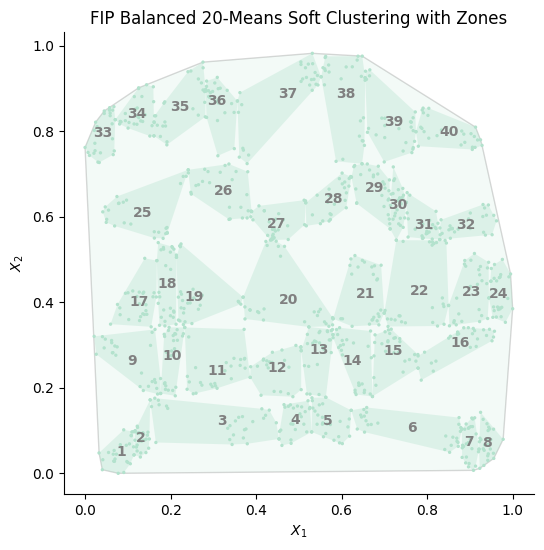

In [ ]:
# --- Parameters ---
popu = 'df_aggregated'
ep_or_up = 'pik_ep'
n = 20
df = popus(n)[popu]
df = rotate_population(df.copy(),0)
N = len(df)

r_sample_per_cluster = 20
centroid_grid_x = 1
num_zones_cluster = [1]
num_zones_sweep = [(8, 10)]
num_splits = [1]
topological = False
shift_jumps = [0, ]
shuffle=False

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
# inclusions_data = inclusion_probabilities(np.random.random(N), n)
# print(inclusions_data)
variable_data = target_df['z'].to_numpy() if 'z' in target_df.columns else inclusions_data

# --- Population & Clustering ---
pop = gs.Population(coords_data, inclusions_data, n=n, variable=variable_data)

fbn = gs.clustering.FIPBalancedNMeans(
    n=n, 
    centroid_grid_x=centroid_grid_x, 
    r_sample_per_cluster=r_sample_per_cluster, 
    init_clust_method='expanded', 
    split_size=1
)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_yx')

# --- Visualization ---
fbn.plot(mode='soft')

### Pre-Process

In [74]:
# --- Parameters ---
# Re-ordered to put None and lexico_yx first (establish a strong baseline early)
point_strategies = [ 'lexico_yx', 'projection', 'spiral', 'angle', 
                    'dist_from_origin', 'dist_from_centroids', 'max_coord', 'lexico_xy']
        

zone_strategies = [ 'lexico_yx', 'projection', 'spiral', 'angle', 
                   'dist_from_origin', 'dist_from_centroids', 'max_coord', 'lexico_xy']
                  

zone_modes = ['sweep_xy', 'sweep_yx']
# Ensure shift_jumps is defined in your notebook before this

initial_designs = []
track = []
min_moran = float('inf') 

# Correct calculation for total iterations
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits) * len(shift_jumps)

# Initialize Progress Bar
pbar = tqdm(product(point_strategies, zone_strategies, zone_modes, num_splits, shift_jumps), total=num_designs)

for point_strategy, zone_strategy, zone_mode, num_split, shift_jump in pbar:
    
    # Selection of zone counts
    list_of_num_zones = num_zones_cluster if zone_mode == 'cluster' else num_zones_sweep

    for num_zones in list_of_num_zones:
        # 1. Fresh Clustering
        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=centroid_grid_x, 
            r_sample_per_cluster=r_sample_per_cluster, 
            init_clust_method='expanded', 
            split_size=1
        )
        fbn.fit(pop)
        fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
        
        # 2. Build Order
        try:
            # IMPORTANT: Set shuffle=True here to use your new Prime Phase Shift logic
            order = gs.Order.from_clusters(
                pop, 
                fbn.clusters, 
                zone_strategy=zone_strategy, 
                point_strategy=point_strategy, 
                num_splits=num_split,
                topological=topological,
                shift_jump=shift_jump,
                shuffle=shuffle 
            )

            # 3. Create Design
            design = RepairedDesign.from_order(pop, order)

            # 4. Evaluate Moran Index
            moran_val = design.moran[0]
            
            # --- BASELINE FIX: Print the very first valid result ---
            if len(track) == 0:
                min_moran = moran_val
                print(f"[INITIAL BASELINE] Moran: {moran_val:.6f} | ZS: {zone_strategy} | PS: {point_strategy}")

            # --- IMPROVEMENT LOGIC ---
            if moran_val < min_moran:
                min_moran = moran_val
                # Using aligned printing for clarity
                print(f"[NEW BEST] Moran: {moran_val:.6f} | ZS: {str(zone_strategy):<15} | PS: {str(point_strategy):<15} | Jump: {shift_jump}")
            
            # Show live status next to the bar
            pbar.set_postfix({"Best": f"{min_moran:.6f}"})

            initial_designs.append(design)
            track.append((moran_val, design, zone_strategy, point_strategy, zone_mode, num_zones, shift_jump))
            
        except Exception as e:
            # If everything shows nothing, comment out 'continue' and uncomment 'raise e' to see why
            continue

# --- Final Ranking Output ---
if not track:
    print("\n[ERROR] No designs were successfully generated. Check your try/except block.")
else:
    results = sorted(track, key=lambda x: x[0])
    best = results[0]

    print(f"\n{'='*40}")
    print(f"      OPTIMIZATION COMPLETE")
    print(f"{'='*40}")
    print(f"Best Moran:      {best[0]:.6f}")
    print(f"Zone Strategy:   {best[2]}")
    print(f"Point Strategy:  {best[3]}")
    print(f"Zone Mode:       {best[4]}")
    print(f"Num Zones:       {best[5]}")
    print(f"Shift Jump:      {best[6]}")
    print(f"{'='*40}")

  1%|          | 1/128 [00:00<01:59,  1.07it/s, Best=-0.102849]

[INITIAL BASELINE] Moran: -0.102849 | ZS: lexico_yx | PS: lexico_yx


  2%|▏         | 3/128 [00:01<01:06,  1.87it/s, Best=-0.129917]

[NEW BEST] Moran: -0.129917 | ZS: lexico_yx       | PS: lexico_yx       | Jump: 0


  9%|▉         | 12/128 [00:03<00:16,  6.90it/s, Best=-0.203116]

[NEW BEST] Moran: -0.140731 | ZS: dist_from_centroids | PS: lexico_yx       | Jump: 0
[NEW BEST] Moran: -0.203116 | ZS: dist_from_centroids | PS: lexico_yx       | Jump: 0


100%|██████████| 128/128 [00:19<00:00,  6.60it/s, Best=-0.203116]


      OPTIMIZATION COMPLETE
Best Moran:      -0.203116
Zone Strategy:   dist_from_centroids
Point Strategy:  lexico_yx
Zone Mode:       sweep_yx
Num Zones:       (8, 5)
Shift Jump:      0


In [75]:
z = sorted(track, key=lambda x: x[0], reverse=False)
# Add 'jump' to the end of the unpacking list
initial_moran, initial_design, zs, ps, zm, nz, jump = z[0]
len(initial_design.all_samples_and_probs[0])
initial_design.all_samples_and_probs[1].sum()

np.float32(1.0)

In [76]:
# target_id is the unit index you want to check (e.g., unit 1)
target_id = 1
empirical_inclu = 0
N = len(df)
samples, probs = initial_design.all_samples_and_probs

for i in range(len(probs)):
    # Check if target_id exists in the i-th sample
    if target_id in samples[i]:
        # Add the probability of this sample occurring
        empirical_inclu += probs[i]

print(f"Empirical Inclusion for unit {target_id}: {empirical_inclu:.6f}")
print(f"Theoretical (n/N): {n/N:.6f}")


Empirical Inclusion for unit 1: 0.019474
Theoretical (n/N): 0.019474


In [77]:
import numpy as np

# 1. Get the empirical FIP (calculated from your repaired samples)
empirical_fip = design.fip

# 2. Get the target FIP (the ones originally defined in the population)
target_fip = design.pop.inclusions

# 3. Calculate the difference
diff = empirical_fip - target_fip

# 4. Print the summary of results
print(f"--- Inclusion Probability Check ---")
print(f"Sum of Empirical FIP: {empirical_fip.sum():.4f} (Should be {design.pop.n})")
print(f"Max Absolute Deviation: {np.abs(diff).max():.2e}")
print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

# Check if they are 'close enough' within a tolerance (e.g., 1e-6)
if np.allclose(empirical_fip, target_fip, atol=1e-6):
    print("SUCCESS: Inclusion probabilities are preserved!")
else:
    print("WARNING: There is a significant deviation in inclusion probabilities.")

--- Inclusion Probability Check ---
Sum of Empirical FIP: 20.0000 (Should be 20)
Max Absolute Deviation: 1.95e-02
Mean Absolute Deviation: 2.53e-04


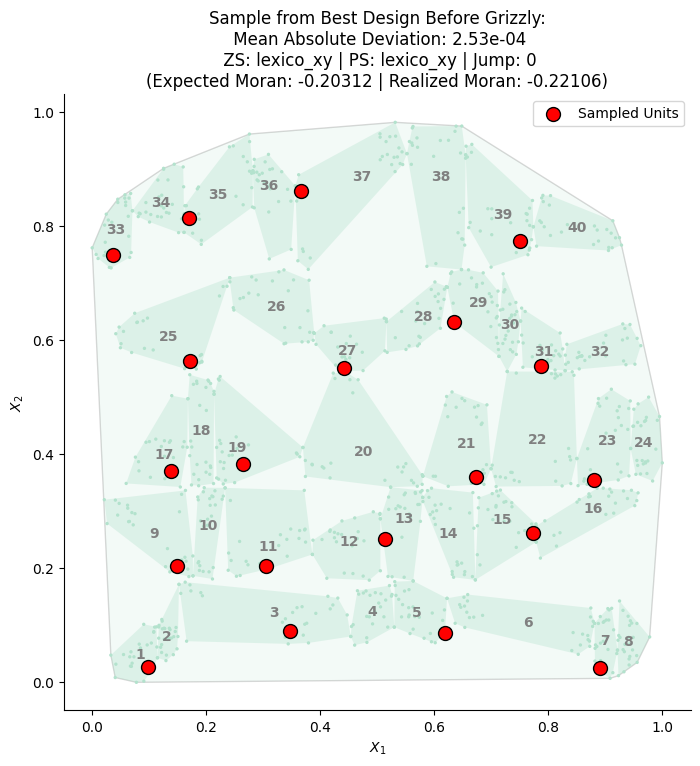

Sampled Unit Indices: [ 384  323  581  264  905  975  463  855   92  222  546  291  997  487
   42  172 1009  949   56  703]


In [78]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use the best design
best_design = initial_design 

# 3. Draw the background (Clustering and Zones)
fbn.plot(mode='soft', ax=ax)

# 4. Extract a SINGLE sample (2D array: 1 row, n columns)
sample_indices_2d = best_design.sample(1)
sample_indices = sample_indices_2d[0] 

# 5. Calculate Moran for this SPECIFIC realization
# We use the Moran indexer on the current coordinates
realized_moran = Moran(best_design.pop).score(sample_indices_2d)[0]

# 6. Scatter the sampled points in Red
all_coords = best_design.pop.coords
ax.scatter(
    all_coords[sample_indices, 0], 
    all_coords[sample_indices, 1], 
    color='red', 
    s=100, 
    edgecolors='black', 
    label='Sampled Units',
    zorder=15 
)

# 7. Update title with both Expected and Realized Moran
ax.set_title(f"Sample from Best Design Before Grizzly:\n Mean Absolute Deviation: {np.abs(diff).mean():.2e}\n ZS: {str(zone_strategy):<5} | PS: {str(point_strategy):<5} | Jump: {shift_jump}\n(Expected Moran: {best_design.moran[0]:.5f} | Realized Moran: {realized_moran:.5f})")
ax.legend()
plt.show()

print(f"Sampled Unit Indices: {sample_indices}")

In [ ]:
print(asdf)

In [64]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


In [65]:
# import os
# import dill as pickle  # dill is more robust for notebook-defined classes

# save_dir_designs = "best_design"
# os.makedirs(save_dir_designs, exist_ok=True) # Ensure directory exists

# filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"
# filepath = os.path.join(save_dir_designs, filename)

# mode = "save"   # Change to "load" when needed

# if mode == "save":
#     # Use the best design found from your simulation results 'z'
#     initial_design_to_save = z[0][1] 
    
#     with open(filepath, "wb") as f:
#         pickle.dump(initial_design_to_save, f)
#     print(f"Design saved to {filepath}")

# elif mode == "load":
#     if os.path.exists(filepath):
#         with open(filepath, "rb") as f:
#             initial_design = pickle.load(f)
#         print(f"Design loaded from {filepath}")
#     else:
#         print("File not found! Check your path or mode.")

### GRIZZLY

In [66]:
# criteria = gs.criteria.MoranCriteria()
# gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)
# gbfs.initial_designs = [initial_design]


In [ ]:
# 1. Define your starting design (from your previous results)
initial_design = results[0][1]

# 2. Define what you are optimizing for (e.g., Moran's I for spatial balance)
criteria = gs.criteria.MoranCriteria()

# 3. Initialize the search with the starting design and criteria
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

# 4. Now you can run your search (e.g., for 100 steps)
# gbfs.search(steps=100)

In [80]:
import graphical_sampling as gs
import numpy as np

def get_fast_hash_sequence(design):
    # Get the internal order array
    o = design.order
    seq = o._order if hasattr(o, '_order') else getattr(o, 'order', o.get())
    
    # If it's a numpy array, return the raw bytes (Fastest!)
    if isinstance(seq, np.ndarray):
        return seq.tobytes()
    # Fallback for standard lists
    return tuple(seq)

# Apply the faster logic to the Design class
gs.Design.__hash__ = lambda self: hash(get_fast_hash_sequence(self))
gs.Design.__eq__ = lambda self, other: isinstance(other, gs.Design) and \
                                       get_fast_hash_sequence(self) == get_fast_hash_sequence(other)


In [69]:
# gbfs.run(
#     max_iterations=1000,        # maximum number of GBFS search iterations (how long the algorithm explores)
#     max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

#     top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

#     num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
#                                 # (creates 20 candidate designs by changing sample order)

#     num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
#                                 # (0 means no swapping of units between samples)

#     num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
#                                 # (clusters are groups of zones processed together)

#     num_zones_range=(0, 0),                # within a cluster, modify only 1 zone at a time

#     num_changes_range=(0, 0),              # each generated neighbor performs one order modification
#                                 # (e.g., one swap/reposition in the sequence)

#     num_zone_changes=8,         # do not reassign samples between zones (zone structure remains fixed)

#     pull_strategy='random',   # rule for selecting samples during exchange operations
#                                 # (not used here since exchange neighbors are disabled)

#     exchange_coef=.5,          # intensity of unit swapping during exchanges
#                                 # (irrelevant here because num_new_exchange_nodes = 0)

#     num_explore=1,               # number of designs expanded per iteration
#                                 # (1 means purely greedy: always expand the current best design)
#     n_jobs = -1
# )


In [70]:
# gbfs.initial_designs =  [gbfs.best_design]

In [82]:
gbfs.run(
    max_iterations=3000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=10,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(0, 0),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(0, 0),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=1,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.5,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    n_jobs = -1
)


--- Starting Parallel GBFS: Max Iterations=3000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.2192
Iter     0/3000 | Best: -0.2192 | Open:     1 | Closed:     0 | moran: -0.2031
238: -0.2196907,  order_change,  DSize:608,  var:0.00, Entp:6.08
Iter   300/3000 | Best: -0.2197 | Open:   658 | Closed:   300 | moran: -0.2188
392: -0.2202212,  order_change,  DSize:643,  var:0.00, Entp:6.21
436: -0.2203227,  order_change,  DSize:662,  var:0.00, Entp:6.24
438: -0.2203489,  order_change,  DSize:668,  var:0.00, Entp:6.25
474: -0.2204920,  order_change,  DSize:669,  var:0.00, Entp:6.23
488: -0.2205937,  order_change,  DSize:613,  var:0.00, Entp:6.16
491: -0.2208041,  order_change,  DSize:671,  var:0.00, Entp:6.28
492: -0.2208453,  order_change,  DSize:683,  var:0.00, Entp:6.28
557: -0.2209046,  order_change,  DSize:649,  var:0.00, Entp:6.22
558: -0.2209574,  order_change,  DSize:636,  var:0.00, Entp:6.20
558: -0.2210875,  order_change,  DSize:649,  var:0.00, Entp:6.21
559: -0.2211

KeyboardInterrupt: 

In [ ]:
gbfs.initial_designs =  [gbfs.best_design]

In [ ]:
import graphical_sampling as gs
import numpy as np

def get_total_state_hash(design):
    # 1. Capture the Order (Sequence)
    o = design.order
    order_data = o._order if hasattr(o, '_order') else o.get()
    
    # 2. Capture the Samples (This is what 'exchange' modifies!)
    # We use the hash of the samples array
    samples, _ = design.all_samples_and_probs
    
    # Combine both into a single hashable signature
    return hash((order_data.tobytes(), samples.tobytes()))

# Inject the new logic into the library
gs.Design.__hash__ = lambda self: get_total_state_hash(self)
gs.Design.__eq__ = lambda self, other: isinstance(other, gs.Design) and \
                                       get_total_state_hash(self) == get_total_state_hash(other)

# NOW re-initialize the search
gbfs.initial_designs = [gbfs.best_design]
# This line is crucial to clear the 'closed_set' and 'open_set' 
# with the new hashing rules in place
gbfs = gs.search.GreedyBestFirstSearch(gbfs.initial_designs, criteria)

In [ ]:
gbfs.run(
    max_iterations=5000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=0,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=100,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.5,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    n_jobs = -1
)


--- Starting Parallel GBFS: Max Iterations=5000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.3595
Iter     0/5000 | Best: -0.3595 | Open:     1 | Closed:     0 | moran: -0.3595


KeyboardInterrupt: 

In [ ]:
import numpy as np

# 1. Get the empirical FIP (calculated from your repaired samples)
empirical_fip = gbfs.best_design.fip

# 2. Get the target FIP (the ones originally defined in the population)
target_fip = design.pop.inclusions

# 3. Calculate the difference
diff = empirical_fip - target_fip

# 4. Print the summary of results
print(f"--- Inclusion Probability Check ---")
print(f"Sum of Empirical FIP: {empirical_fip.sum():.4f} (Should be {design.pop.n})")
print(f"Max Absolute Deviation: {np.abs(diff).max():.2e}")
print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

# Check if they are 'close enough' within a tolerance (e.g., 1e-6)
if np.allclose(empirical_fip, target_fip, atol=1e-6):
    print("SUCCESS: Inclusion probabilities are preserved!")
else:
    print("WARNING: There is a significant deviation in inclusion probabilities.")

--- Inclusion Probability Check ---
Sum of Empirical FIP: 20.0000 (Should be 20)
Max Absolute Deviation: 1.88e-09
Mean Absolute Deviation: 1.60e-09
SUCCESS: Inclusion probabilities are preserved!


In [ ]:
save_dir_designs = "best_design"

filename = f"best_design_{popu}_{n}_{ep_or_up}_zoni.pkl"
filepath = os.path.join(save_dir_designs, filename)

# save your design object
with open(filepath, "wb") as f:
    pickle.dump(gbfs.best_design, f)
gbfs.initial_designs = [gbfs.best_design]

In [ ]:
variable = np.random.randint(N)
srs_var = N**2 * (1-n/N) * np.var(variable)/n
plain_flat = [
    N,
    n,
    5000,
    0,
    np.sum(variable),
    float(gbfs.best_design.nht_variance),
    # float(srs_var / gbfs.best_design.nht_variance),
    0,
    *map(float, gbfs.best_design.density_disparity),
    *map(float, gbfs.best_design.voronoi),
    *map(float, gbfs.best_design.moran),
    *map(float, gbfs.best_design.local_balance),
]
arr = np.array(plain_flat, dtype=float)
simple = [float(x) for x in arr]
# Example: flatten all tuples in the list
flat = []
for x in simple:
    if isinstance(x, tuple):
        flat.extend(x)
    else:
        flat.append(x)

print(', '.join(str(x) for x in flat))




1000.0, 20.0, 5000.0, 0.0, 169.0, 0.0, 0.0, 0.07381125768120418, 0.04771870439577483, 0.04868880389526494, 0.019425811731346596, -0.35561071522567483, 0.03579760973343451, 0.10662277280030831, 0.022715004294433908


In [ ]:
graphical-sampling/simulations/jupyters/sampling.ipynb